# Test auf Normalverteilung – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/test-auf-normalverteilung)

Die **Normalverteilung** ist eine der wichtigsten Voraussetzungen für viele
parametrische Testverfahren. Bevor ein t-Test, eine ANOVA oder eine lineare
Regression berechnet wird, muss geprüft werden, ob die Daten normalverteilt sind.

| Methode | Art | Stärken | Schwächen |
|---|---|---|---|
| **Shapiro-Wilk-Test** | Analytisch | Sehr gut bei kleinen n (< 50) | Sensitiv bei großem n |
| **Kolmogorov-Smirnov-Test** | Analytisch | Auch für andere Verteilungen | Weniger sensitiv als SW |
| **Anderson-Darling-Test** | Analytisch | Gewichtet Ränder stärker | Sensitiv bei großem n |
| **Histogramm + NV-Kurve** | Grafisch | Intuitiv | Subjektiv |
| **Q-Q-Plot** | Grafisch | Beste grafische Methode | Interpretation nötig |

**Hypothesen (bei allen Tests):**
- H₀: Die Daten sind normalverteilt
- H₁: Die Daten sind **nicht** normalverteilt
- p > 0,05 → H₀ nicht ablehnen → Normalverteilung angenommen
- p ≤ 0,05 → H₀ ablehnen → Keine Normalverteilung

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy import stats
from scipy.stats import norm as norm_dist, shapiro, kstest, anderson

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Warum ist die Normalverteilung wichtig?

Viele **parametrische Tests** setzen normalverteilte Daten voraus:

| Test | Voraussetzung |
|---|---|
| t-Test (unabh./abh.) | Abhängige Variable normalverteilt |
| ANOVA | Abhängige Variable normalverteilt je Gruppe |
| Lineare Regression | **Residuen** normalverteilt (nicht die Rohdaten!) |
| Pearson-Korrelation | Beide Variablen normalverteilt |

**Was tun wenn keine Normalverteilung?** → Nichtparametrische Tests verwenden:

| Parametrisch | Nichtparametrisches Äquivalent |
|---|---|
| t-Test unabhängig | Mann-Whitney-U-Test |
| t-Test abhängig | Wilcoxon-Test |
| ANOVA | Kruskal-Wallis-Test |
| Pearson-Korrelation | Spearman-Korrelation |

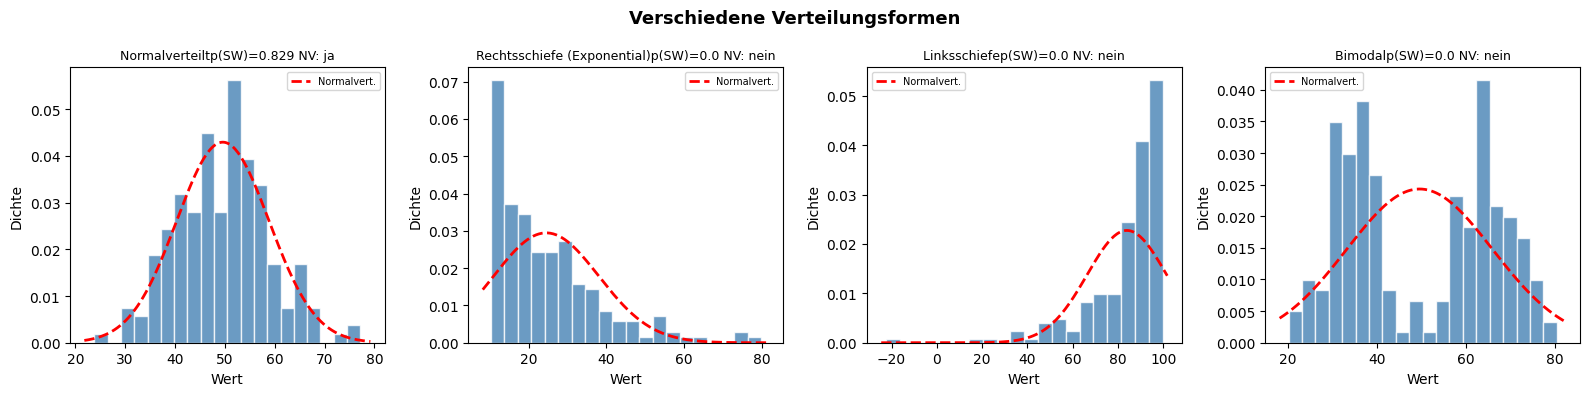

In [2]:
# Vier Verteilungstypen zum Vergleich
np.random.seed(42)
n = 200

daten = {
    "Normalverteilt": np.random.normal(50, 10, n),
    "Rechtsschiefe (Exponential)": np.random.exponential(scale=15, size=n) + 10,
    "Linksschiefe": 100 - np.random.exponential(scale=15, size=n),
    "Bimodal": np.concatenate([
        np.random.normal(35, 6, n//2),
        np.random.normal(65, 6, n//2)
    ])
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Verschiedene Verteilungsformen", fontsize=13, fontweight="bold")

for ax, (name, d) in zip(axes, daten.items()):
    ax.hist(d, bins=20, color="steelblue", edgecolor="white", alpha=0.8, density=True)
    x_r = np.linspace(d.min()-2, d.max()+2, 200)
    y_nv = norm_dist.pdf(x_r, d.mean(), d.std())
    ax.plot(x_r, y_nv, color="red", linewidth=2, linestyle="--", label="Normalvert.")
    _, p_sw = shapiro(d)
    entsch = "NV: ja" if p_sw > 0.05 else "NV: nein"
    ax.set_title(name + "p(SW)=" + str(round(p_sw, 4)) + " " + entsch, fontsize=9)
    ax.set_xlabel("Wert")
    ax.set_ylabel("Dichte")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 2. Shapiro-Wilk-Test

Der **Shapiro-Wilk-Test** ist der empfohlene Test bei **kleinen bis mittleren
Stichproben (n < 50)**. Er ist sensitiver als der Kolmogorov-Smirnov-Test.

**Interpretation:**
- p > 0,05 → H₀ nicht ablehnen → Normalverteilung angenommen ✅
- p ≤ 0,05 → H₀ ablehnen → Keine Normalverteilung ❌

> **Wichtig:** Bei sehr großen Stichproben (n > 1000) findet der Test auch
> kleinste Abweichungen als signifikant – dann besser grafische Methoden nutzen!

In [9]:
# Shapiro-Wilk-Test – Beispiele
np.random.seed(42)
beispiele = {
    "Normalverteilt (n=50)":     np.random.normal(100, 15, 50),
    "Rechtsschiefe (n=50)":      np.random.exponential(10, 50) + 60,
    "Normalverteilt (n=200)":    np.random.normal(100, 15, 200),
    "Leicht schief (n=200)":     stats.skewnorm.rvs(a=3, loc=80, scale=15, size=200),
}

print("Shapiro-Wilk-Test")
print(f"{'Datensatz':<30}  {'n':>5}  {'W-Statistik':>12}  {'p-Wert':>10}  {'Ergebnis'}")
print()
for name, d in beispiele.items():
    w, p = shapiro(d)
    entsch = "Normalverteilt" if p > 0.05 else "NICHT normalvert."
    print(f"{name:<30}  {len(d):>5}  {w:>12.4f}  {p:>10.4f}  {entsch}")

Shapiro-Wilk-Test
Datensatz                           n   W-Statistik      p-Wert  Ergebnis

Normalverteilt (n=50)              50        0.9827      0.6722  Normalverteilt
Rechtsschiefe (n=50)               50        0.8617      0.0000  NICHT normalvert.
Normalverteilt (n=200)            200        0.9882      0.0952  Normalverteilt
Leicht schief (n=200)             200        0.9822      0.0123  NICHT normalvert.


## 3. Kolmogorov-Smirnov und Anderson-Darling Test

### Kolmogorov-Smirnov-Test (KS-Test)
- Vergleicht die empirische Verteilungsfunktion mit der theoretischen Normalverteilung
- Kann auch für andere Verteilungen verwendet werden
- **Etwas weniger sensitiv** als Shapiro-Wilk

### Anderson-Darling-Test (AD-Test)
- Ähnlich wie KS-Test, gewichtet aber die **Ränder der Verteilung** stärker
- Gibt kritische Werte für verschiedene Signifikanzniveaus aus (0,15 / 0,10 / 0,05 / 0,025 / 0,01)
- Teststatistik > kritischer Wert → H₀ ablehnen

In [11]:
# Alle drei analytischen Tests im Vergleich
np.random.seed(7)
daten_nv   = np.random.normal(50, 10, 80)
daten_nnv  = np.random.exponential(scale=10, size=80) + 20

def alle_tests(d, name):
    # Shapiro-Wilk
    w_sw, p_sw = shapiro(d)

    # Kolmogorov-Smirnov (Daten standardisieren fuer norm-Test)
    d_std = (d - d.mean()) / d.std()
    ks_stat, p_ks = kstest(d_std, "norm")

    # Anderson-Darling
    ad_res = anderson(d, dist="norm")
    ad_stat = ad_res.statistic
    # p-Wert naeherungsweise aus kritischen Werten
    sig_levels = [0.15, 0.10, 0.05, 0.025, 0.01]
    krit_werte = ad_res.critical_values
    ad_p_approx = "< 0.01" if ad_stat > krit_werte[-1] else (
                  "< 0.05" if ad_stat > krit_werte[2] else "> 0.05")

    print(f"{name} (n={len(d)})")
    print(f"Shapiro-Wilk:          W={w_sw:.4f},  p={p_sw:.4f}  -> "
          + ("Normalverteilt" if p_sw > 0.05 else "NICHT normalvert."))
    print(f"Kolmogorov-Smirnov:    D={ks_stat:.4f},  p={p_ks:.4f}  -> "
          + ("Normalverteilt" if p_ks > 0.05 else "NICHT normalvert."))
    print(f"Anderson-Darling:      A={ad_stat:.4f},  p approx {ad_p_approx}  -> "
          + ("Normalverteilt" if ad_p_approx == "> 0.05" else "NICHT normalvert."))

print("Vergleich aller drei analytischen Tests")
alle_tests(daten_nv,  "Normalverteilte Daten")
alle_tests(daten_nnv, "Exponentialverteilung (nicht NV)")

Vergleich aller drei analytischen Tests
Normalverteilte Daten (n=80)
Shapiro-Wilk:          W=0.9804,  p=0.2577  -> Normalverteilt
Kolmogorov-Smirnov:    D=0.0683,  p=0.8242  -> Normalverteilt
Anderson-Darling:      A=0.4656,  p approx > 0.05  -> Normalverteilt
Exponentialverteilung (nicht NV) (n=80)
Shapiro-Wilk:          W=0.8547,  p=0.0000  -> NICHT normalvert.
Kolmogorov-Smirnov:    D=0.1588,  p=0.0314  -> NICHT normalvert.
Anderson-Darling:      A=2.8861,  p approx < 0.01  -> NICHT normalvert.


## 4. Das n-Problem: Nachteil analytischer Tests

**Kernproblem (numiqo):** Der p-Wert hängt stark von der Stichprobengröße ab.

- **Kleines n:** Auch stark nicht-normalverteilte Daten → p > 0,05 → fälschlicherweise als NV eingestuft
- **Großes n:** Selbst minimale Abweichungen → p < 0,05 → Normalverteilung abgelehnt

> **Deshalb:** Immer **zusätzlich** grafische Methoden (Q-Q-Plot, Histogramm) verwenden!

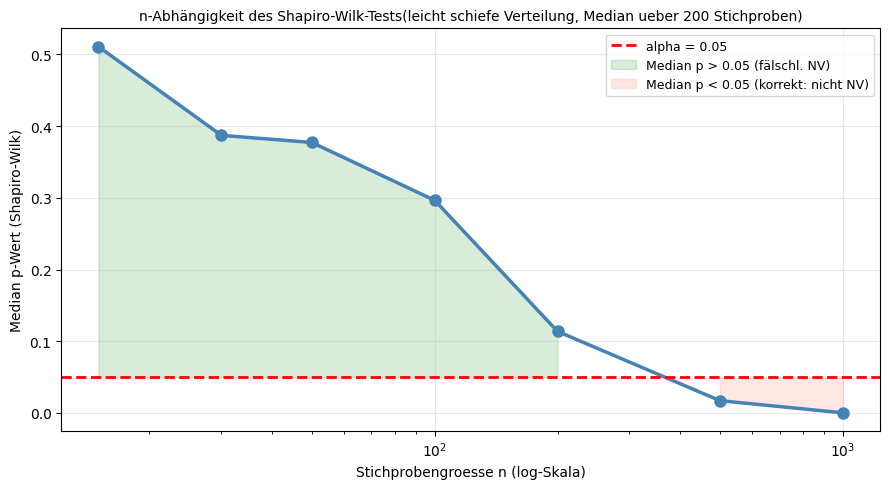

Fazit: Bei n < 50 wird die leicht schiefe Verteilung fälschlicherweise
als normalverteilt eingestuft. Bei n > 200 wird sie korrekt abgelehnt.
-> Immer auch grafische Methoden verwenden!


In [13]:
# Demonstration des n-Problems
np.random.seed(42)

# Leicht schiefe Grundgesamtheit (Schiefe = 0.5)
def stichprobe_ziehen(n):
    return stats.skewnorm.rvs(a=1.5, loc=50, scale=12, size=n)

n_werte = [15, 30, 50, 100, 200, 500, 1000]
p_werte_sw = []

for n_s in n_werte:
    ps_list = [shapiro(stichprobe_ziehen(n_s))[1] for _ in range(200)]
    p_werte_sw.append(np.median(ps_list))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_werte, p_werte_sw, "o-", color="steelblue", linewidth=2.5, markersize=8)
ax.axhline(0.05, color="red", linestyle="--", linewidth=2, label="alpha = 0.05")
ax.fill_between(n_werte, p_werte_sw, 0.05,
                where=[p > 0.05 for p in p_werte_sw],
                alpha=0.15, color="green", label="Median p > 0.05 (fälschl. NV)")
ax.fill_between(n_werte, p_werte_sw, 0.05,
                where=[p < 0.05 for p in p_werte_sw],
                alpha=0.15, color="tomato", label="Median p < 0.05 (korrekt: nicht NV)")
ax.set_xscale("log")
ax.set_title("n-Abhängigkeit des Shapiro-Wilk-Tests(leicht schiefe Verteilung, Median ueber 200 Stichproben)",
             fontsize=10)
ax.set_xlabel("Stichprobengroesse n (log-Skala)")
ax.set_ylabel("Median p-Wert (Shapiro-Wilk)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Fazit: Bei n < 50 wird die leicht schiefe Verteilung fälschlicherweise")
print("als normalverteilt eingestuft. Bei n > 200 wird sie korrekt abgelehnt.")
print("-> Immer auch grafische Methoden verwenden!")

## 5. Grafische Prüfung: Histogramm mit Normalverteilungskurve

Das **Histogramm** ist der einfachste grafische Check. Die Normalverteilungskurve
wird eingezeichnet und optisch verglichen.

**Merkmale einer Normalverteilung:**
- Glockenförmige, symmetrische Kurve
- Einziger Gipfel in der Mitte
- Kein starker Unterschied zwischen Mittelwert und Median

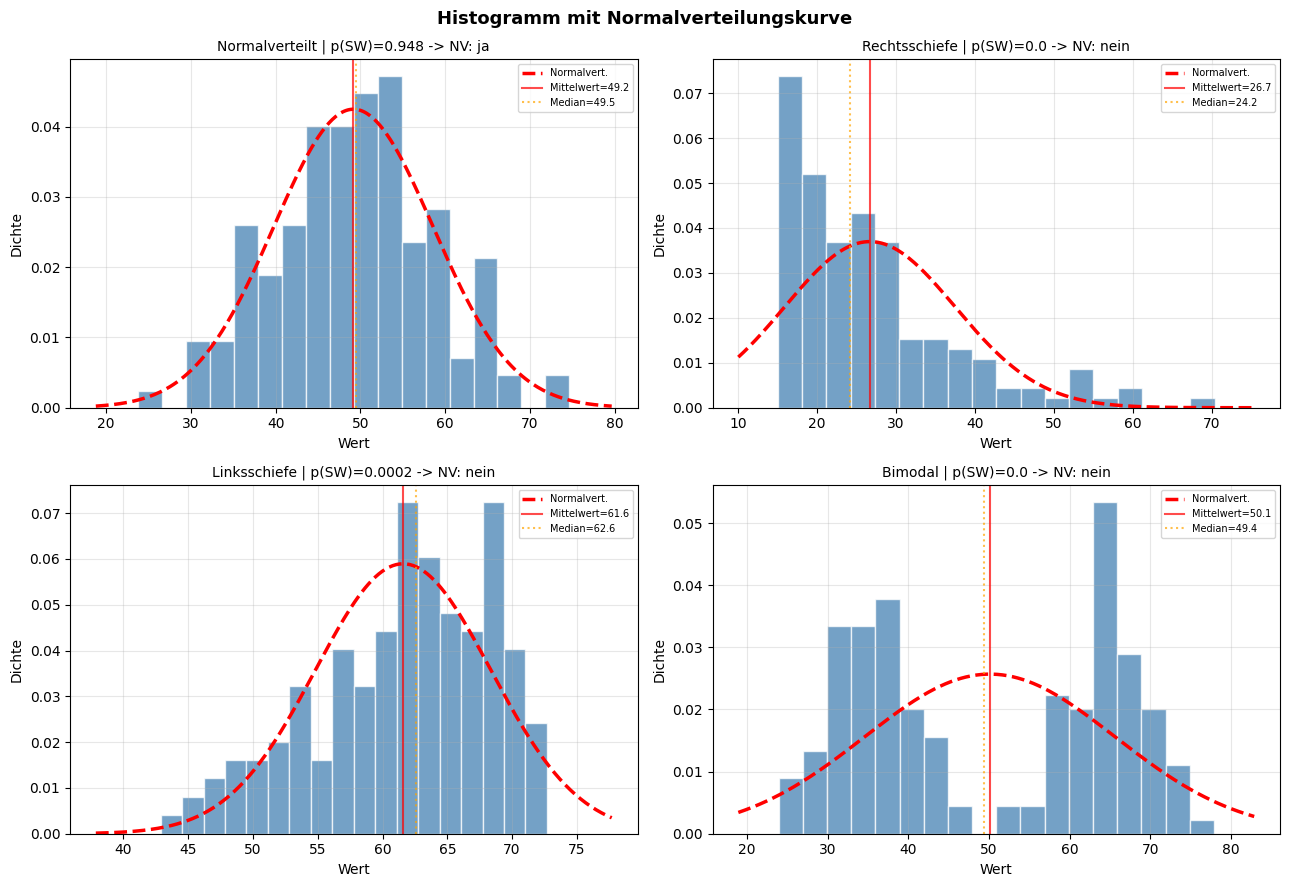

In [6]:
# Histogramm mit NV-Kurve – vier Verteilungen
np.random.seed(42)
n = 150

vier_daten = [
    (np.random.normal(50, 10, n),                                   "Normalverteilt"),
    (np.random.exponential(scale=12, size=n) + 15,                  "Rechtsschiefe"),
    (stats.skewnorm.rvs(a=-5, loc=70, scale=12, size=n),            "Linksschiefe"),
    (np.concatenate([np.random.normal(35,5,n//2),
                     np.random.normal(65,5,n//2)]),                  "Bimodal"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Histogramm mit Normalverteilungskurve", fontsize=13, fontweight="bold")

for ax, (d, name) in zip(axes.flat, vier_daten):
    w_sw, p_sw = shapiro(d)
    ax.hist(d, bins=18, color="steelblue", edgecolor="white", alpha=0.75, density=True)
    x_r = np.linspace(d.min()-5, d.max()+5, 300)
    y_nv = norm_dist.pdf(x_r, d.mean(), d.std())
    ax.plot(x_r, y_nv, color="red", linewidth=2.5, linestyle="--", label="Normalvert.")
    ax.axvline(d.mean(),   color="red",    linestyle="-",  linewidth=1.5, alpha=0.7,
               label="Mittelwert=" + str(round(d.mean(), 1)))
    ax.axvline(np.median(d), color="orange", linestyle=":",  linewidth=1.5, alpha=0.7,
               label="Median=" + str(round(np.median(d), 1)))
    entsch = "NV: ja" if p_sw > 0.05 else "NV: nein"
    ax.set_title(name + " | p(SW)=" + str(round(p_sw, 4)) + " -> " + entsch, fontsize=10)
    ax.set_xlabel("Wert")
    ax.set_ylabel("Dichte")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Grafische Prüfung: Q-Q-Plot (Quantil-Quantil-Plot)

Der **Q-Q-Plot** ist die **beste grafische Methode** zur Normalverteilungsprüfung
(numiqo-Empfehlung).

**Aufbau:**
- x-Achse: Theoretische Quantile (bei perfekter Normalverteilung erwartet)
- y-Achse: Beobachtete Quantile der Daten
- **Diagonale Linie:** Perfekte Normalverteilung

**Interpretation:**
| Muster | Bedeutung |
|---|---|
| Punkte liegen auf der Linie | Normalverteilt ✅ |
| S-förmige Kurve | Schwere Ränder / Ausreißer |
| Bogen nach oben | Rechtsschiefe |
| Bogen nach unten | Linksschiefe |
| Punkte weichen an den Enden ab | Leichte Nicht-Normalität |

> **numiqo** zeigt zusätzlich das **95%-Konfidenzintervall** – liegen alle Punkte
> darin, ist das ein starker Hinweis auf Normalverteilung.

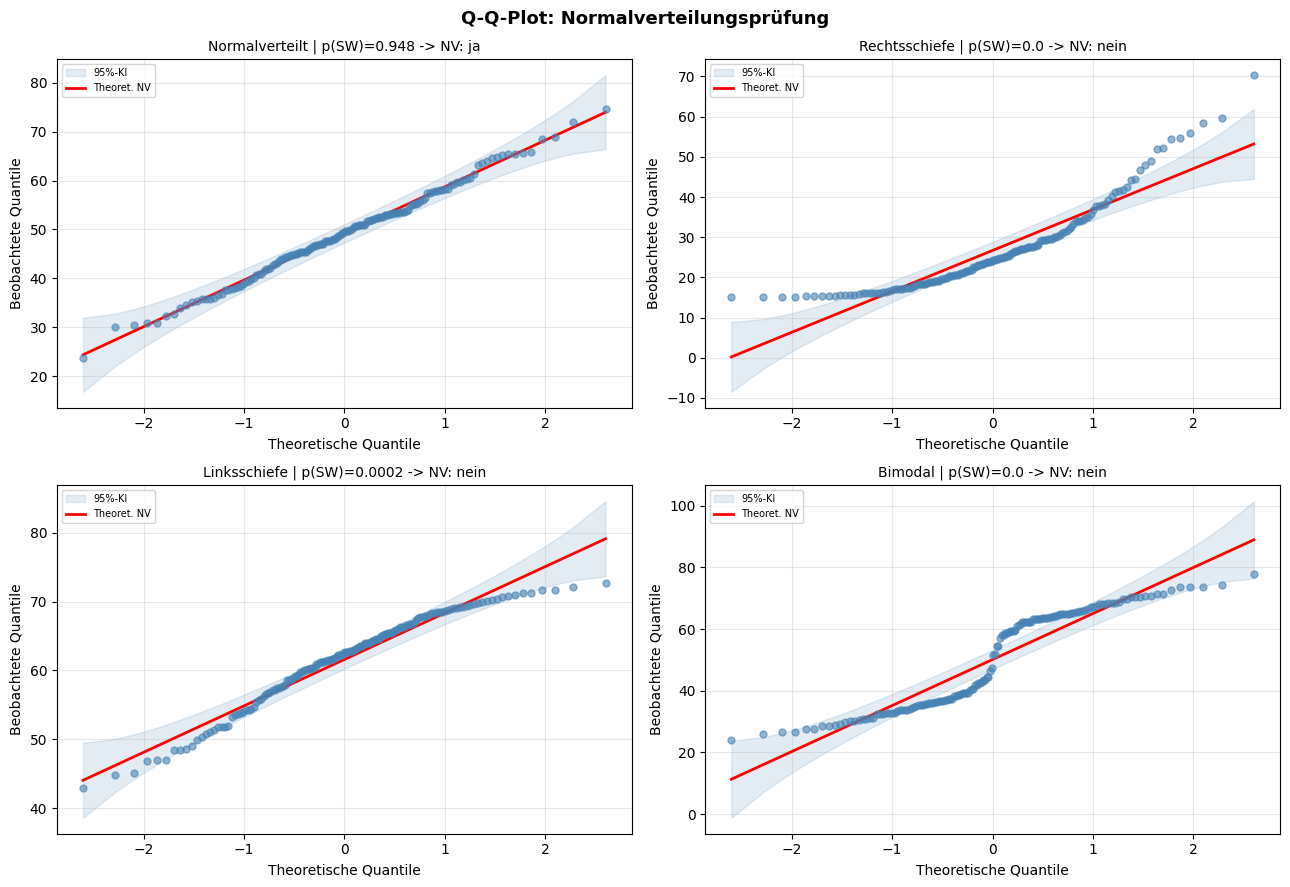

In [14]:
# Q-Q-Plot – vier Verteilungen
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Q-Q-Plot: Normalverteilungsprüfung", fontsize=13, fontweight="bold")

for ax, (d, name) in zip(axes.flat, vier_daten):
    # Q-Q-Plot mit Konfidenzband
    (osm, osr), (slope, intercept, r) = stats.probplot(d, dist="norm")

    # 95%-Konfidenzband (näherungsweise)
    n_d = len(d)
    se  = (1 / norm_dist.pdf(osm)) * np.sqrt(
          (norm_dist.cdf(osm) * (1 - norm_dist.cdf(osm))) / n_d)
    y_fit = slope * osm + intercept
    ci_faktor = 1.96

    ax.fill_between(osm,
                    y_fit - ci_faktor * se * d.std(),
                    y_fit + ci_faktor * se * d.std(),
                    alpha=0.15, color="steelblue", label="95%-KI")
    ax.scatter(osm, osr, color="steelblue", alpha=0.6, s=25, zorder=3)
    ax.plot(osm, y_fit, color="red", linewidth=2, label="Theoret. NV")

    w_sw, p_sw = shapiro(d)
    entsch = "NV: ja" if p_sw > 0.05 else "NV: nein"
    ax.set_title(name + " | p(SW)=" + str(round(p_sw, 4)) + " -> " + entsch, fontsize=10)
    ax.set_xlabel("Theoretische Quantile")
    ax.set_ylabel("Beobachtete Quantile")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Vollständige Normalverteilungsprüfung (wie numiqo)

numiqo zeigt beide Methoden gemeinsam: erst die analytischen Tests als Tabelle,
dann die grafischen Methoden.

Normalverteilungspruefung: Körpergröße (cm)

n=80  MW=168.76  SD=9.51  Schiefe=-0.175  Kurtosis=-0.320

Analytische Tests
  Shapiro-Wilk:         W=0.9896, p=0.7720 -> Normalverteilt
  Kolmogorov-Smirnov:   D=0.0453, p=0.9943 -> Normalverteilt
  Anderson-Darling:     A=0.1826, p approx > 0.05 -> Normalverteilt



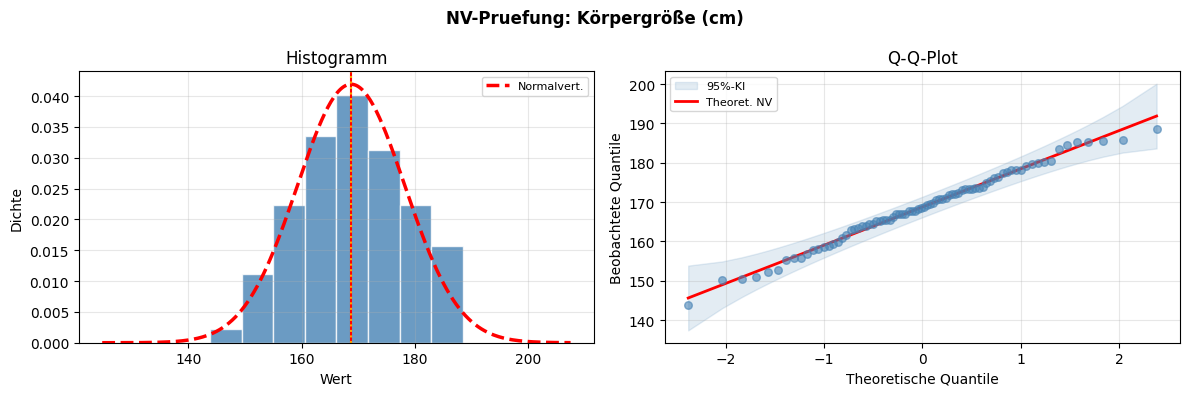

Normalverteilungspruefung: Gehalt (EUR) - nicht normalverteilt

n=80  MW=2623.65  SD=1171.16  Schiefe=1.468  Kurtosis=1.587

Analytische Tests
  Shapiro-Wilk:         W=0.8219, p=0.0000 -> NICHT NV
  Kolmogorov-Smirnov:   D=0.1709, p=0.0164 -> NICHT NV
  Anderson-Darling:     A=4.6365, p approx < 0.01 -> NICHT NV



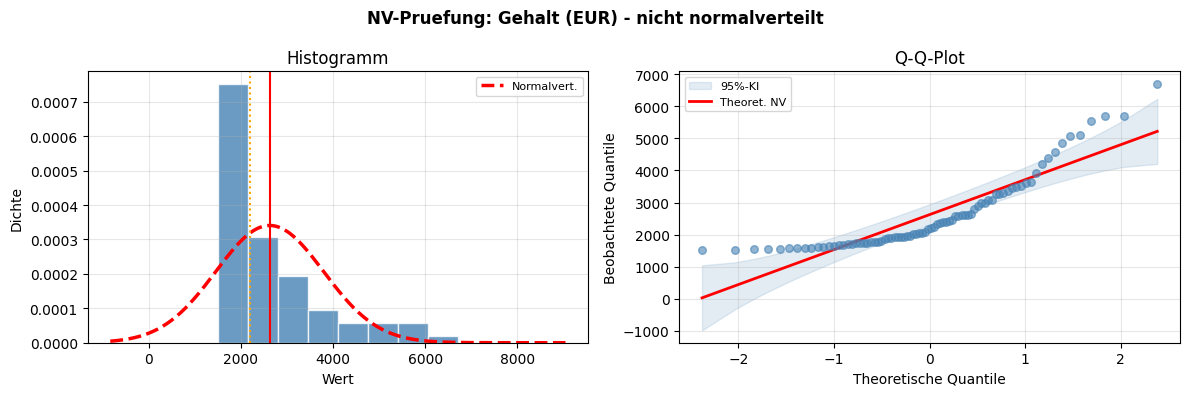

In [16]:
# Vollstaendige NV-Pruefung fuer einen Datensatz
def normalverteilung_pruefen(daten, variablenname="Variable"):
    d = np.asarray(daten)
    n = len(d)

    print("Normalverteilungspruefung: " + variablenname)
    print()
    print(f"n={n}  MW={d.mean():.2f}  SD={d.std():.2f}  "
          f"Schiefe={stats.skew(d):.3f}  Kurtosis={stats.kurtosis(d):.3f}")
    print()

    # Analytische Tests
    print("Analytische Tests")
    w_sw, p_sw = shapiro(d)
    d_std = (d - d.mean()) / d.std()
    ks_s,  p_ks = kstest(d_std, "norm")
    ad_res       = anderson(d, dist="norm")

    ad_p = "< 0.01" if ad_res.statistic > ad_res.critical_values[4] else (
           "< 0.05" if ad_res.statistic > ad_res.critical_values[2] else "> 0.05")

    print(f"  Shapiro-Wilk:         W={w_sw:.4f}, p={p_sw:.4f} "
          + ("-> Normalverteilt" if p_sw > 0.05 else "-> NICHT NV"))
    print(f"  Kolmogorov-Smirnov:   D={ks_s:.4f}, p={p_ks:.4f} "
          + ("-> Normalverteilt" if p_ks > 0.05 else "-> NICHT NV"))
    print(f"  Anderson-Darling:     A={ad_res.statistic:.4f}, p approx {ad_p} "
          + ("-> Normalverteilt" if ad_p == "> 0.05" else "-> NICHT NV"))
    print()

    # Grafische Pruefung
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("NV-Pruefung: " + variablenname, fontsize=12, fontweight="bold")

    # Histogramm
    axes[0].hist(d, bins=int(np.sqrt(n)), color="steelblue",
                 edgecolor="white", alpha=0.8, density=True)
    x_r = np.linspace(d.min()-2*d.std(), d.max()+2*d.std(), 300)
    axes[0].plot(x_r, norm_dist.pdf(x_r, d.mean(), d.std()),
                 color="red", linewidth=2.5, linestyle="--", label="Normalvert.")
    axes[0].axvline(d.mean(), color="red",    linestyle="-", linewidth=1.5)
    axes[0].axvline(np.median(d), color="orange", linestyle=":", linewidth=1.5)
    axes[0].set_title("Histogramm")
    axes[0].set_xlabel("Wert")
    axes[0].set_ylabel("Dichte")
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)

    # Q-Q-Plot
    (osm, osr), (slope, intercept, _) = stats.probplot(d, dist="norm")
    se = (1 / norm_dist.pdf(osm)) * np.sqrt(
         (norm_dist.cdf(osm) * (1 - norm_dist.cdf(osm))) / n)
    y_fit = slope * osm + intercept
    axes[1].fill_between(osm, y_fit - 1.96*se*d.std(),
                              y_fit + 1.96*se*d.std(),
                         alpha=0.15, color="steelblue", label="95%-KI")
    axes[1].scatter(osm, osr, color="steelblue", alpha=0.6, s=30, zorder=3)
    axes[1].plot(osm, y_fit, color="red", linewidth=2, label="Theoret. NV")
    axes[1].set_title("Q-Q-Plot")
    axes[1].set_xlabel("Theoretische Quantile")
    axes[1].set_ylabel("Beobachtete Quantile")
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# Test 1: Körpergroesse (normalverteilt)
np.random.seed(42)
koerpergroesse = np.random.normal(170, 10, 80)
normalverteilung_pruefen(koerpergroesse, "Körpergröße (cm)")

# Test 2: Gehalt (rechtsschiefe)
np.random.seed(42)
gehalt = np.random.exponential(scale=1200, size=80) + 1500
normalverteilung_pruefen(gehalt, "Gehalt (EUR) - nicht normalverteilt")

## 8. Zusammenfassung

```
Test auf Normalverteilung – Übersicht
│
├── WARUM?
│   Voraussetzung fuer: t-Test, ANOVA, Pearson-Korrelation, lin. Regression
│   Wenn nicht NV -> nichtparametrische Tests verwenden
│
├── HYPOTHESEN
│   H0: Daten sind normalverteilt
│   H1: Daten sind NICHT normalverteilt
│   p > 0.05 -> H0 nicht ablehnen -> Normalverteilung angenommen
│   p <= 0.05 -> H0 ablehnen -> NICHT normalverteilt
│
├── ANALYTISCHE TESTS
│   ├── Shapiro-Wilk       -> empfohlen fuer n < 50
│   ├── Kolmogorov-Smirnov -> auch fuer andere Verteilungen
│   └── Anderson-Darling   -> gewichtet Raender staerker
│   NACHTEIL: p-Wert stark abhaengig von n
│   -> bei kleinem n: faelschl. als NV eingestuft
│   -> bei grossem n: kleinste Abweichungen signifikant
│
├── GRAFISCHE METHODEN (immer zusaetzlich!)
│   ├── Histogramm + NV-Kurve
│   │   Einfach, intuitiv, subjektiv
│   │
│   └── Q-Q-Plot (BESTE METHODE)
│       x-Achse: theoretische Quantile
│       y-Achse: beobachtete Quantile
│       Punkte auf Linie = normalverteilt
│       + 95%-Konfidenzband (wie bei numiqo)
│       Muster:
│         Bogen oben    = Rechtsschiefe
│         Bogen unten   = Linksschiefe
│         S-Form        = Schwere Raender
│
└── EMPFEHLUNG (numiqo)
    1. Shapiro-Wilk berechnen (bei n < 50)
    2. IMMER Q-Q-Plot ansehen
    3. Histogramm als zusaetzliche Kontrolle
    4. Bei Widerspruch: grafischer Eindruck bevorzugen
```

---
Quelle: [numiqo.de/tutorial/test-auf-normalverteilung](https://numiqo.de/tutorial/test-auf-normalverteilung)